In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import re

# 1. Load dataset
df = pd.read_csv('/content/drive/MyDrive/Skripsi/Dataset/FIX DATASET/Data20uji.csv')  # Ganti nama file sesuai kebutuhan

jumlah_duplikat = df.duplicated(subset='text').sum()
print(f"[INFO] Jumlah duplikat berdasarkan text: {jumlah_duplikat}")

# Tampilkan data duplikat
duplikat_clean_text = df[df.duplicated(subset='text', keep=False)]
print("\n[INFO] Contoh duplikat:\n", duplikat_clean_text.head())

# Hapus duplikat
df_cleaned = df.drop_duplicates(subset='text', keep='first')
print(f"[INFO] Jumlah data setelah menghapus duplikat: {len(df_cleaned)}")

# Simpan hasil
df_cleaned.to_csv('/content/drive/MyDrive/Skripsi/Dataset/FIX DATASET/DataTidakDuplikat.csv', index=False)
print("[INFO] Data berhasil disimpan")


[INFO] Jumlah duplikat berdasarkan text: 0

[INFO] Contoh duplikat:
 Empty DataFrame
Columns: [username, screen_name, text, created_at, retweets, likes]
Index: []
[INFO] Jumlah data setelah menghapus duplikat: 152
[INFO] Data berhasil disimpan


#Labeling data

In [ ]:
!pip install transformers torch


In [ ]:
from transformers import pipeline, AutoModelForSequenceClassification, AutoTokenizer

model_id = "w11wo/indonesian-roberta-base-sentiment-classifier"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSequenceClassification.from_pretrained(model_id)

sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/FIX DATASET/Data20uji_clean.csv")

texts = df['clean_text'].astype(str).tolist()

# Prediksi sentimen
results = sentiment_pipeline(texts)

# Tambahkan ke DataFrame
df['sentiment'] = [r['label'] for r in results]
df['confidence'] = [r['score'] for r in results]

df.to_csv("/content/drive/MyDrive/Skripsi/Dataset/20Roberta/robertahasil150.csv", index=False)

print("Pelabelan selesai! File disimpan sebagai csv")



Pelabelan selesai! File disimpan sebagai csv


In [ ]:
df.tail(50)

,username,screen_name,text,created_at,retweets,likes,sentiment,confidence
5654,Andromeda,hanyagagabutan,@yaniarsim @aniesbaswedan Masuk 100 tokoh inte...,Wed Feb 26 20:52:12 +0000 2025,0,6,negative,0.998136
5655,Mipan,mipan221,"@sauceterannaa @tanyakanrl Emang labanya, shru...",Wed Feb 26 20:49:35 +0000 2025,0,1,negative,0.811409
5656,💕 INRI,Mat16_16,Rp. 193 T dibagi 7 tuyul\nMasing2 dapat Rp. 27...,Wed Feb 26 20:43:55 +0000 2025,0,0,negative,0.988768
5657,✨️ Pfau,12Dinda_,@Pitoeng206 @NOTASLIMBOY Usaha kowi cari dana ...,Wed Feb 26 20:37:31 +0000 2025,0,0,negative,0.996833
5658,@lucihappy1,lucihappy11,@Simemaki CALON TRIO KORUPTOR DANANTARA,Wed Feb 26 20:37:00 +0000 2025,0,0,neutral,0.981050
5659,arrijal,Abu_shahib16,@KangManto123 Karena danantara sudah rampung,Wed Feb 26 20:35:05 +0000 2025,0,0,neutral,0.996000
5660,Hans Seringham,seringham62617,@erickthohir Korupsi Pertamina membuat rakyat ...,Wed Feb 26 20:29:11 +0000 2025,1,35,negative,0.507292
5661,Muchson Arrosyid,MuchsonA95358,@OposisiCerdas Dana pindah danantara kah ?,Wed Feb 26 20:27:30 +0000 2025,0,0,neutral,0.868268
5662,-,ovaltine1411,@TakumiYozora @tvhanalg @Arie_Kriting jujur iy...,Wed Feb 26 20:27:02 +0000 2025,0,0,negative,0.968539
5663,Ireng,IrenggnerI,pagar laut kena rayap\nmelon abis digigit tiku...,Wed Feb 26 20:26:15 +0000 2025,0,0,negative,0.998454


In [ ]:

df_low_conf = df[df['confidence'] < 0.7]

# Cek jumlah total
print(f"Jumlah data dengan confidence < 0.7: {len(df_low_conf)}")

# Cek distribusi sentimen pada data tersebut
print("\nDistribusi sentimen dari data yang confidence-nya < 0.7:")
print(df_low_conf['sentiment'].value_counts())


Jumlah data dengan confidence < 0.7: 1773

Distribusi sentimen dari data yang confidence-nya < 0.7:
sentiment
neutral     680
negative    628
positive    465
Name: count, dtype: int64


In [ ]:
print("Jumlah data sebelum dihapus:", len(df))

df = df[df['confidence'] >= 0.7]

print("Jumlah data setelah dihapus:", len(df))

df.to_csv('/content/drive/MyDrive/Skripsi/Dataset/FIX DATASET/labelrobertasudahconfidence.csv', index=False)

Jumlah data sebelum dihapus: 15032
Jumlah data setelah dihapus: 13259


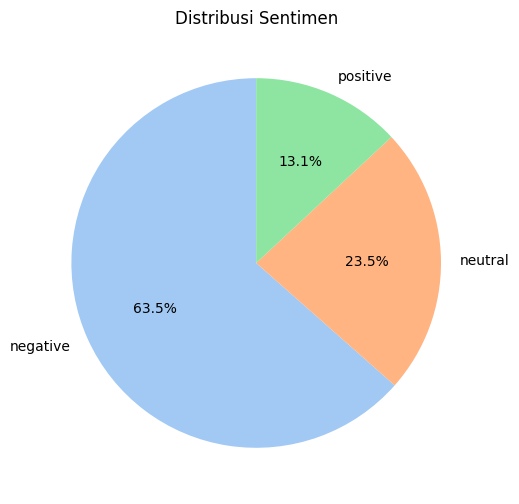

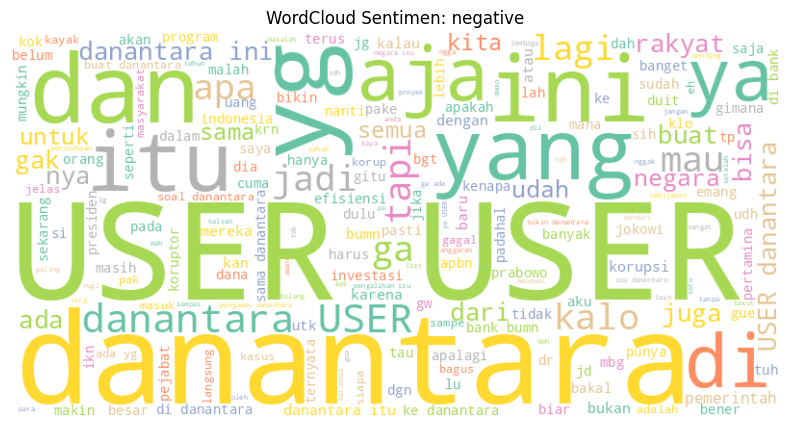

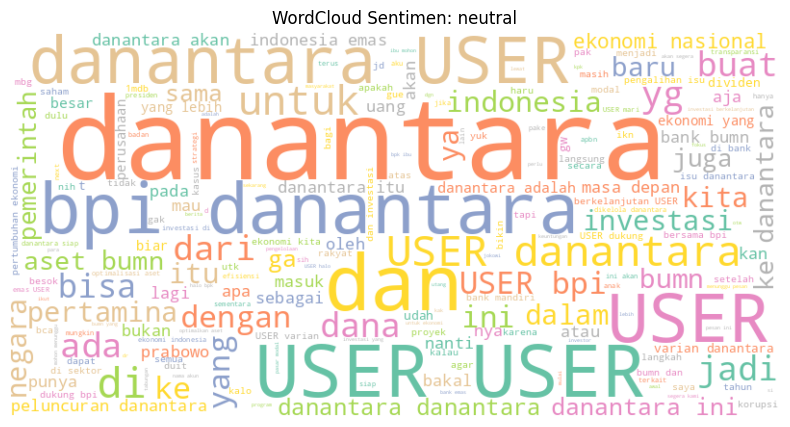

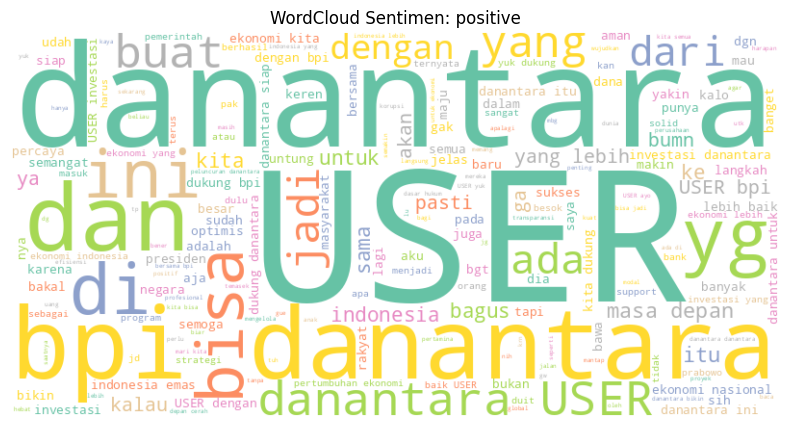

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

# === Load Data ===
df = pd.read_csv('/content/drive/MyDrive/Skripsi/Dataset/FIX DATASET/labelrobertasudahconfidence.csv')

# === Pie Chart Distribusi Sentimen ===
plt.figure(figsize=(6, 6))
df['sentiment'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90,
                                    colors=sns.color_palette('pastel'))
plt.title('Distribusi Sentimen')
plt.ylabel('')  # Menghilangkan label Y
plt.show()

# === WordCloud untuk Masing-masing Sentimen ===
labels = df['sentiment'].unique()
for label in labels:
    text = ' '.join(df[df['sentiment'] == label]['clean_text'].astype(str))

    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          max_words=200, colormap='Set2').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud Sentimen: {label}')
    plt.show()


In [ ]:
import pandas as pd

# 1. Load dataset
df = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/FIX DATASET/siapmodel1.csv")

# Misal kolom teks bernama 'clean_text'
text_column = 'clean_text'

# 2. Hitung jumlah kata
df['word_count'] = df[text_column].astype(str).apply(lambda x: len(x.split()))

# 3. Filter agar hanya post dengan >= 5 kata
df_filtered = df[df['word_count'] >= 5].copy()

# 4. Hapus kolom 'word_count' jika tidak mau disimpan
df_filtered.drop(columns=['word_count'], inplace=True)

# 5. Simpan hasil
df_filtered.to_csv("/content/drive/MyDrive/Skripsi/Dataset/FIX DATASET/siapmodel1_>5.csv", index=False)

print(f"Data awal: {len(df)}, Data setelah filter: {len(df_filtered)}")


Data awal: 14393, Data setelah filter: 13511


# AWAL BARU

In [ ]:
!pip install sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 13.5 MB/s eta 0:00:00


In [ ]:
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords
import nltk
import pandas as pd

nltk.download('stopwords')
df = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/FIX DATASET/Data20uji.csv")
df = df[df['text'].str.split().str.len() >= 5]

# Inisialisasi
stop_words = set(stopwords.words('indonesian'))
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def clean_text_exact(text, debug=False, log_file=None, idx=None):
    if pd.isna(text):
        return ""

    def log(msg):
        if log_file:
            with open(log_file, "a", encoding="utf-8") as f:
                f.write(f"[{idx}] {msg}\n")

    if debug: log(f"=== TEXT ASLI ===\n{text}")

    # Ganti mention menjadi [USER]
    text = re.sub(r'@\w+', '[USER]', text)
    if debug: log(f"Setelah ganti mention: {text}")

    # Casefolding kecuali [USER]
    text = re.sub(r'\[USER\]', '<<TEMPUSER>>', text)
    text = text.lower()
    text = re.sub(r'<<tempuser>>', '[USER]', text)
    if debug: log(f"Setelah casefolding: {text}")

    # Hapus URL
    text = re.sub(r'http\S+|www\.\S+', '', text)
    if debug: log(f"Setelah hapus URL: {text}")

    # Hilangkan tanda # tapi simpan teks setelahnya
    text = re.sub(r'#', '', text)
    if debug: log(f"Setelah hapus hashtag: {text}")

    # Hapus emoji & karakter non-ASCII
    text = text.encode('ascii', 'ignore').decode('ascii')
    if debug: log(f"Setelah hapus emoji: {text}")

    # Hapus tanda baca selain huruf, angka, spasi, ?, !, [, ]
    text = re.sub(r'[^a-zA-Z0-9\s\[\]!?]', '', text)
    if debug: log(f"Setelah hapus tanda baca: {text}")

    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    if debug: log(f"Setelah hapus spasi berlebih: {text}")

    # Tokenisasi
    tokens = text.split()
    if debug: log(f"Tokenisasi: {tokens}")

    # Stopword removal
    no_stopwords = [word for word in tokens if word not in stop_words]
    if debug: log(f"Setelah stopword removal: {no_stopwords}")

    # Stemming
    stemmed = [word if word == "[USER]" else stemmer.stem(word) for word in no_stopwords]
    if debug: log(f"Setelah stemming: {stemmed}")

    final_text = " ".join(stemmed)
    if debug: log(f"=== HASIL AKHIR ===\n{final_text}\n")

    return final_text


# 🔎 Tracking 100 data pertama dan simpan log ke file .txt
log_file = "/content/drive/MyDrive/Skripsi/Dataset/debug_log_100.txt"
open(log_file, "w").close()  # reset file

for i in range(min(150, len(df))):
    _ = clean_text_exact(df['text'].iloc[i], debug=True, log_file=log_file, idx=i)

print(f"✅ Debug 100 data pertama tersimpan di: {log_file}")

# Terapkan preprocessing penuh
df['clean_text'] = df['text'].apply(clean_text_exact)
df.to_csv("/content/drive/MyDrive/Skripsi/Dataset/FIX DATASET/Data20uji_clean(test).csv", index=False)
print("✅ Preprocessing selesai & file tersimpan.")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


✅ Debug 100 data pertama tersimpan di: /content/drive/MyDrive/Skripsi/Dataset/debug_log_100.txt
✅ Preprocessing selesai & file tersimpan.
